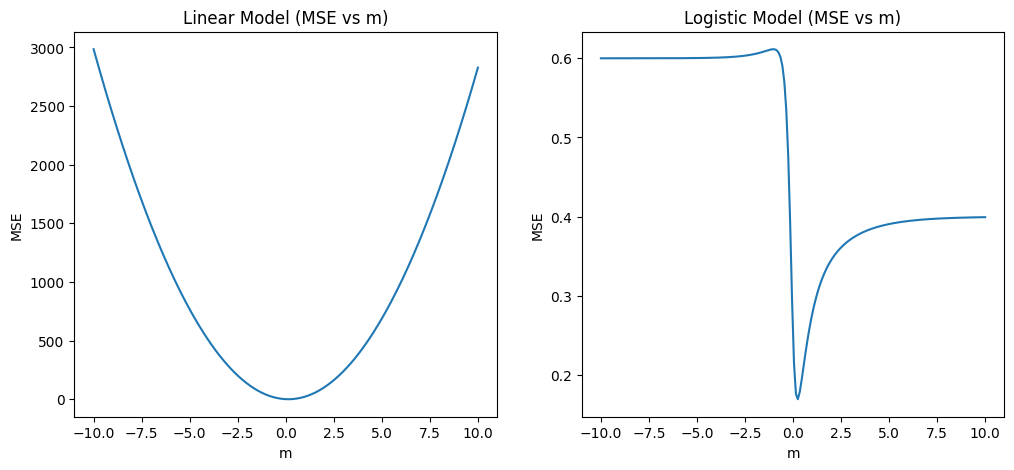

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Dataset
X = np.array([0.5, 0.8, 1.2, 1.5, 2.0, 2.4, 2.8, 3.1, 3.5, 4.2,
              5.2, 5.5, 5.8, 6.2, 6.5, 7.1, 7.8, 8.2, 8.9, 9.5])

Y = np.array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
              1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

# Models
def linear_model(x, m):
    return m * x

def logistic_model(x, m):
    return 1 / (1 + np.exp(-m * x))

# MSE
def mse(y_pred, y_true):
    return np.mean((y_pred - y_true) ** 2)

m_values = np.linspace(-10, 10, 200)

mse_linear = []
mse_logistic = []

for m in m_values:
    mse_linear.append(mse(linear_model(X, m), Y))
    mse_logistic.append(mse(logistic_model(X, m), Y))

# Plot
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(m_values, mse_linear)
plt.title("Linear Model (MSE vs m)")
plt.xlabel("m")
plt.ylabel("MSE")

plt.subplot(1,2,2)
plt.plot(m_values, mse_logistic)
plt.title("Logistic Model (MSE vs m)")
plt.xlabel("m")
plt.ylabel("MSE")

plt.show()

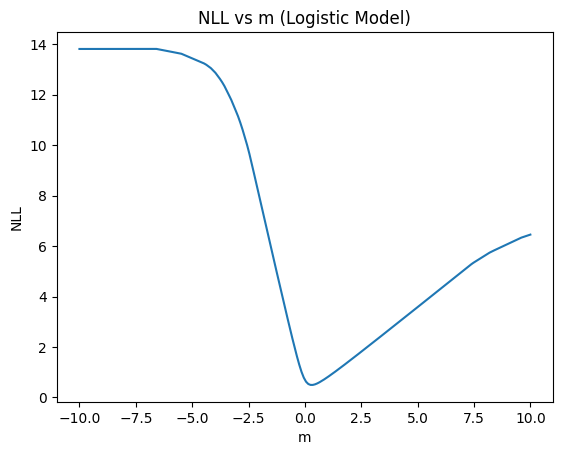

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Dataset
X = np.array([0.5, 0.8, 1.2, 1.5, 2.0, 2.4, 2.8, 3.1, 3.5, 4.2,
              5.2, 5.5, 5.8, 6.2, 6.5, 7.1, 7.8, 8.2, 8.9, 9.5])

Y = np.array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
              1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

# Logistic Model
def logistic_model(x, m):
    return 1 / (1 + np.exp(-m * x))

# NLL Loss
def nll(y_pred, y_true):
    epsilon = 1e-10
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(y_true*np.log(y_pred) + (1-y_true)*np.log(1-y_pred))

m_values = np.linspace(-10, 10, 200)
nll_values = []

for m in m_values:
    y_pred = logistic_model(X, m)
    nll_values.append(nll(y_pred, Y))

# Plot
plt.plot(m_values, nll_values)
plt.title("NLL vs m (Logistic Model)")
plt.xlabel("m")
plt.ylabel("NLL")
plt.show()

In [ ]:
import numpy as np

# Dataset
X = np.array([0.5, 0.8, 1.2, 1.5, 2.0, 2.4, 2.8, 3.1, 3.5, 4.2,
              5.2, 5.5, 5.8, 6.2, 6.5, 7.1, 7.8, 8.2, 8.9, 9.5])

Y = np.array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
              1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

# Model
def logistic_model(x, m, c):
    return 1 / (1 + np.exp(-(m*x + c)))

# Losses
def mse(y_pred, y_true):
    return np.mean((y_pred - y_true) ** 2)

def nll(y_pred, y_true):
    epsilon = 1e-10
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(y_true*np.log(y_pred) + (1-y_true)*np.log(1-y_pred))

# -----------------------
# Simulated Annealing
# -----------------------
def simulated_annealing():
    m, c = np.random.uniform(-1,1), np.random.uniform(-1,1)
    T = 1.0

    while T > 1e-3:
        new_m = m + np.random.normal(0,0.5)
        new_c = c + np.random.normal(0,0.5)

        old_loss = mse(logistic_model(X,m,c), Y)
        new_loss = mse(logistic_model(X,new_m,new_c), Y)

        if new_loss < old_loss or np.random.rand() < np.exp((old_loss-new_loss)/T):
            m, c = new_m, new_c

        T *= 0.9

    return m, c

# -----------------------
# Hill Climbing
# -----------------------
def hill_climbing():
    m, c = 0, 0
    step = 0.1

    while True:
        current_loss = nll(logistic_model(X,m,c), Y)

        candidates = [
            (m+step, c), (m-step, c),
            (m, c+step), (m, c-step)
        ]

        best = (m, c)
        best_loss = current_loss

        for nm, nc in candidates:
            loss = nll(logistic_model(X,nm,nc), Y)
            if loss < best_loss:
                best = (nm, nc)
                best_loss = loss

        if abs(best_loss - current_loss) < 1e-5:
            break

        m, c = best

    return m, c

# Run
m1, c1 = simulated_annealing()
m2, c2 = hill_climbing()

print("Simulated Annealing (MSE): m =", m1, "c =", c1)
print("Hill Climbing (NLL): m =", m2, "c =", c2)

Simulated Annealing (MSE): m = 1.0073081470884842 c = -3.174455457884984
Hill Climbing (NLL): m = 2.800000000000001 c = -9.499999999999982


In [ ]:
import numpy as np

# Dataset
X = np.array([0.5, 0.8, 1.2, 1.5, 2.0, 2.4, 2.8, 3.1, 3.5, 4.2,
              5.2, 5.5, 5.8, 6.2, 6.5, 7.1, 7.8, 8.2, 8.9, 9.5])

Y = np.array([0,0,0,0,0,0,0,0,1,1,
              1,1,1,1,1,1,1,1,1,1])

# Logistic Model
def logistic(x, m, c):
    return 1 / (1 + np.exp(-(m*x + c)))

# MSE Loss
def mse(y_pred, y_true):
    return np.mean((y_pred - y_true) ** 2)

# Simulated Annealing
def simulated_annealing():
    m, c = np.random.uniform(-1,1), np.random.uniform(-1,1)
    T = 1.0
    alpha = 0.9

    while T > 1e-3:
        new_m = m + np.random.normal(0, 0.5)
        new_c = c + np.random.normal(0, 0.5)

        old_loss = mse(logistic(X, m, c), Y)
        new_loss = mse(logistic(X, new_m, new_c), Y)

        # Accept new solution
        if new_loss < old_loss or np.random.rand() < np.exp((old_loss - new_loss)/T):
            m, c = new_m, new_c

        T *= alpha

    return m, c, new_loss

# Run
m, c, loss = simulated_annealing()

print("Simulated Annealing Result:")
print("m =", m)
print("c =", c)
print("MSE Loss =", loss)

Simulated Annealing Result:
m = -11.352949683619196
c = 1.247066216565293
MSE Loss = 0.6000069475196426


In [ ]:
import numpy as np

# Dataset
X = np.array([0.5, 0.8, 1.2, 1.5, 2.0, 2.4, 2.8, 3.1, 3.5, 4.2,
              5.2, 5.5, 5.8, 6.2, 6.5, 7.1, 7.8, 8.2, 8.9, 9.5])

Y = np.array([0,0,0,0,0,0,0,0,1,1,
              1,1,1,1,1,1,1,1,1,1])

# Logistic Model
def logistic(x, m, c):
    return 1 / (1 + np.exp(-(m*x + c)))

# NLL Loss
def nll(y_pred, y_true):
    epsilon = 1e-10
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(y_true*np.log(y_pred) + (1-y_true)*np.log(1-y_pred))

# Hill Climbing
def hill_climbing():
    m, c = 0, 0
    step = 0.1

    while True:
        current_loss = nll(logistic(X, m, c), Y)

        neighbors = [
            (m+step, c), (m-step, c),
            (m, c+step), (m, c-step)
        ]

        best_m, best_c = m, c
        best_loss = current_loss

        for nm, nc in neighbors:
            loss = nll(logistic(X, nm, nc), Y)
            if loss < best_loss:
                best_loss = loss
                best_m, best_c = nm, nc

        # Stop condition
        if abs(current_loss - best_loss) < 1e-5:
            break

        m, c = best_m, best_c

    return m, c, best_loss

# Run
m, c, loss = hill_climbing()

print("Hill Climbing Result:")
print("m =", m)
print("c =", c)
print("NLL Loss =", loss)

Hill Climbing Result:
m = 2.800000000000001
c = -9.499999999999982
NLL Loss = 0.06459131149466303
